# CREMA-D Training Template

A starting point for training an emotion classifier on the CREMA-D spectrogram dataset.

**How to use this template:**
- Run cells from top to bottom.
- Edit the **Configuration** cell to set your batch size, learning rate, image size, and number of epochs.
- Replace the model in the **Model Definition** section with your own architecture.
- Rename this file before you start (e.g. `train_resnet50.ipynb`) so it does not conflict with other team members' notebooks.

**Prerequisites:**
- Python environment active (venv or conda — see `README.md`).
- `data/` folder present in this directory (see `README.md` for the download link).
- Run this notebook from the `training/` directory.

This notebook installs its own Python dependencies via `!pip install` cells — no manual package installation required beyond having Jupyter available.

## 0) Python dependencies

In [3]:
import subprocess, sys

# Core training dependencies
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "torch", "torchvision",
    "matplotlib",
    "scikit-learn",
    "tqdm",
    "numpy",
])

import torch
import torchvision
print(f"torch       {torch.__version__}")
print(f"torchvision {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

torch       2.5.1
torchvision 0.20.1
CUDA available: True


## 1) Imports

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

## 2) Configuration

Edit the values in this cell to suit your experiment.

In [5]:
# ── Paths ──────────────────────────────────────────────────────────────────
# Assumes this notebook is run from the training/ directory.
# If not, set DATA_DIR manually, e.g.: DATA_DIR = Path("/absolute/path/to/data")
DATA_DIR = Path.cwd() / "data"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

# ── Image settings ─────────────────────────────────────────────────────────
# Spectrograms are 640×640 grayscale PNGs.
# Resize to 224×224 for compatibility with most pretrained backbones.
# Increase if your GPU allows — larger images retain more detail.
IMAGE_SIZE = 224

# ── Training hyperparameters ───────────────────────────────────────────────
BATCH_SIZE    = 16
NUM_EPOCHS    = 100
LEARNING_RATE = 5e-5  # Lower LR for fine-tuning pretrained model and additional layers
NUM_WORKERS   = 0     # Use 0 on Windows to avoid DataLoader worker hangs

# ── Dataset ────────────────────────────────────────────────────────────────
CLASS_NAMES = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]
NUM_CLASSES = len(CLASS_NAMES)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Output ─────────────────────────────────────────────────────────────────
MODEL_SAVE_PATH = Path("model.pth")

print(f"Data dir : {DATA_DIR}")
print(f"Device   : {DEVICE}")
print(f"Classes  : {CLASS_NAMES}")

Data dir : c:\Users\Jing Rong\Git\ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER\SystemCode\data\training\data
Device   : cuda
Classes  : ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']


## 3) Verify data structure

In [6]:
assert DATA_DIR.exists(), (
    f"data/ not found at {DATA_DIR}.\n"
    "Download it from the shared drive link in training/README.md and extract it here."
)

print(f"{'Split':<8} {'Emotion':<8} {'PNGs':>6} {'WAVs':>6}")
print("-" * 34)
total_png = total_wav = 0
for split, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        assert cls_dir.exists(), f"Missing expected directory: {cls_dir}"
        n_png = len(list(cls_dir.glob("*.png")))
        n_wav = len(list(cls_dir.glob("*.wav")))
        total_png += n_png
        total_wav += n_wav
        print(f"{split:<8} {cls:<8} {n_png:>6} {n_wav:>6}")

print("-" * 34)
print(f"{'TOTAL':<17} {total_png:>6} {total_wav:>6}")
print("\nData structure OK.")

Split    Emotion    PNGs   WAVs
----------------------------------
train    ANG        1006   1006
train    DIS        1006   1006
train    FEA        1006   1006
train    HAP        1006   1006
train    NEU         860    860
train    SAD        1006   1006
test     ANG         265    265
test     DIS         265    265
test     FEA         265    265
test     HAP         265    265
test     NEU         227    227
test     SAD         265    265
----------------------------------
TOTAL               7442   7442

Data structure OK.


## 4) Dataset and data loaders

`ImageFolder` loads PNGs from subdirectories named by class label — matching exactly how the data is organised.
The spectrograms are grayscale, so we convert to RGB to work with standard 3-channel model architectures.

In [7]:
class SpecAugment:
    def __init__(self, time_mask=40, freq_mask=30):
        self.time_mask = time_mask
        self.freq_mask = freq_mask
    def __call__(self, spec):
        _, H, W = spec.shape
        if W > self.time_mask:
            t = torch.randint(0, W - self.time_mask, (1,))
            spec[:, :, t:t+self.time_mask] = 0
        if H > self.freq_mask:
            f = torch.randint(0, H - self.freq_mask, (1,))
            spec[:, f:f+self.freq_mask, :] = 0
        return spec

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomAffine(degrees=8, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    SpecAugment(time_mask=40, freq_mask=30),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

train_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_transforms)
test_dataset  = datasets.ImageFolder(root=str(TEST_DIR),  transform=test_transforms)

from torch.utils.data import WeightedRandomSampler

targets = [label for _, label in train_dataset.samples]
class_sample_counts = np.bincount(targets, minlength=NUM_CLASSES)
weights = 1. / class_sample_counts
sample_weights = [weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)

test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)

counts = np.bincount([label for _, label in train_dataset.samples], minlength=NUM_CLASSES)
class_weights = torch.tensor(counts.max() / counts, dtype=torch.float32, device=DEVICE)

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Class counts : {counts.tolist()}")
print(f"Class mapping : {train_dataset.class_to_idx}")

Train samples : 5890
Test  samples : 1552
Class counts : [1006, 1006, 1006, 1006, 860, 1006]
Class mapping : {'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}


### Visualise a batch

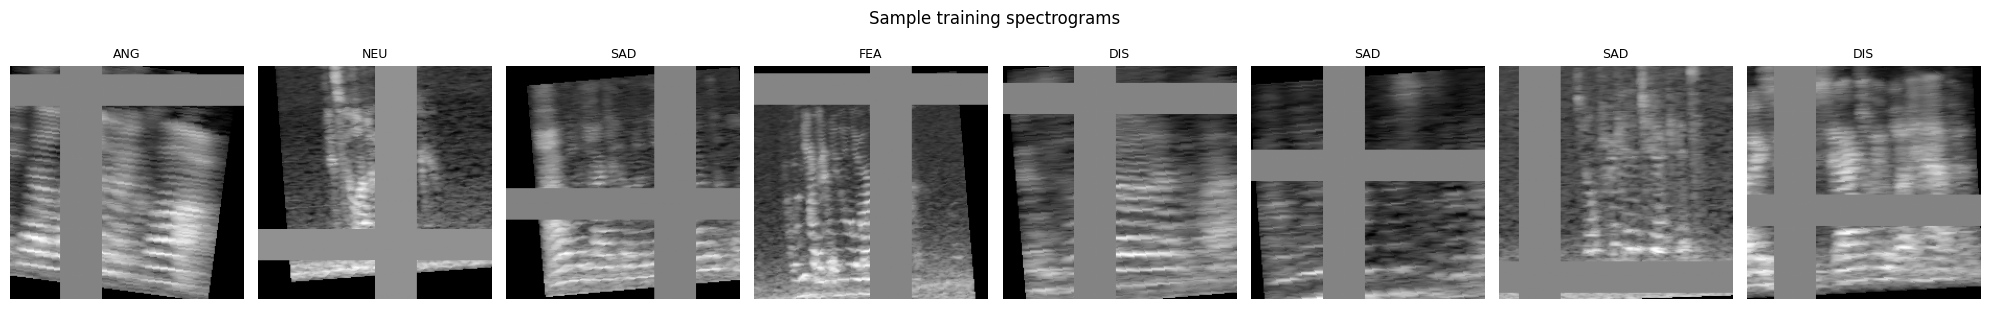

In [8]:
def denorm(tensor):
    """Reverse the 0.5/0.5 normalisation for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

images, labels = next(iter(train_loader))
n_show = min(8, len(images))

fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
for i, ax in enumerate(axes):
    img = denorm(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img[:, :, 0], cmap="gray")
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample training spectrograms", y=1.02)
plt.tight_layout()
plt.show()

## 5) Model definition

Using ResNet50 pretrained on ImageNet for emotion classification.

In [9]:
import torchvision.models as models

# Load pretrained ResNet50
model = models.resnet50(weights="IMAGENET1K_V1")

# Freeze all pretrained layers by default
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Unfreeze layer3, layer4, and head for fine-tuning
for name, param in model.named_parameters():
    if name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model)

Trainable parameters: 22,075,398
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256

In [10]:
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


In [11]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def run_epoch(loader, training: bool):
    model.train(training)
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, desc="train" if training else "eval ", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
                # Apply Mixup
                images, y_a, y_b, lam = mixup_data(images, labels)
                outputs = model(images)
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
                loss.backward()
                optimizer.step()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item() * len(labels)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

early_stopping = EarlyStopping(patience=10, min_delta=0.001)

for epoch in range(1, NUM_EPOCHS + 1):
    # Progressive unfreezing
    if epoch == 10:
        for name, param in model.named_parameters():
            if name.startswith("layer2"):
                param.requires_grad = True
        print("Unfroze layer2 at epoch 10")

    # Training and evaluation
    train_loss, train_acc = run_epoch(train_loader, training=True)
    test_loss,  test_acc  = run_epoch(test_loader,  training=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch:>3}/{NUM_EPOCHS}  "
          f"train loss {train_loss:.4f}  acc {train_acc:.4f}  "
          f"| test loss {test_loss:.4f}  acc {test_acc:.4f}")

    # Early stopping check
    early_stopping.step(test_loss)
    if early_stopping.should_stop:
        print(f"Early stopping triggered at epoch {epoch}")
        break


Epoch   1/100  train loss 1.6479  acc 0.2801  | test loss 1.9825  acc 0.3860


Epoch   2/100  train loss 1.5753  acc 0.2920  | test loss 1.5608  acc 0.4414


Epoch   3/100  train loss 1.5418  acc 0.3171  | test loss 1.6251  acc 0.4381


Epoch   4/100  train loss 1.5267  acc 0.3248  | test loss 1.5894  acc 0.5238


Epoch   5/100  train loss 1.5026  acc 0.3463  | test loss 1.3903  acc 0.5122


...

Epoch  18/100  train loss 1.3796  acc 0.3688  | test loss 1.3326  acc 0.5773


Epoch  19/100  train loss 1.3590  acc 0.3723  | test loss 1.3611  acc 0.5606


Epoch  20/100  train loss 1.3598  acc 0.3769  | test loss 1.4203  acc 0.5470


Epoch  21/100  train loss 1.3740  acc 0.3798  | test loss 1.4490  acc 0.5277


Epoch  22/100  train loss 1.3345  acc 0.3954  | test loss 1.3114  acc 0.5844
Early stopping triggered at epoch 22


### Training curves

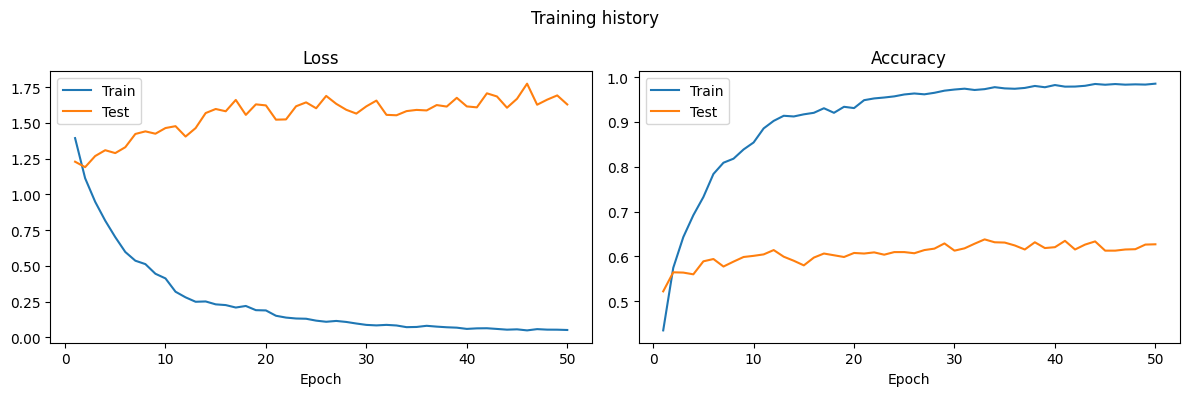

: 

: 

: 

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], label="Train")
ax1.plot(epochs, history["test_loss"],  label="Test")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs, history["train_acc"], label="Train")
ax2.plot(epochs, history["test_acc"],  label="Test")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.suptitle("Training history")
plt.tight_layout()
plt.show()

## 7) Evaluation

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="evaluating"):
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

evaluating: 100%|██████████| 97/97 [00:36<00:00,  2.65it/s]

              precision    recall  f1-score   support

         ANG       0.72      0.72      0.72       265
         DIS       0.59      0.57      0.58       265
         FEA       0.53      0.60      0.56       265
         HAP       0.60      0.68      0.64       265
         NEU       0.73      0.64      0.68       227
         SAD       0.63      0.54      0.58       265

    accuracy                           0.63      1552
   macro avg       0.63      0.63      0.63      1552
weighted avg       0.63      0.63      0.63      1552



: 

: 

: 

### Confusion matrix

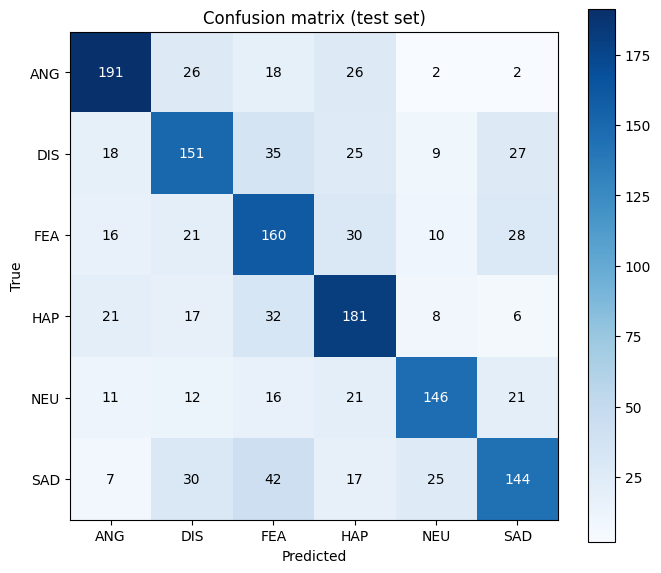

: 

: 

: 

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test set)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

## 8) Save the model

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names":      CLASS_NAMES,
    "image_size":       IMAGE_SIZE,
    "num_classes":      NUM_CLASSES,
}, MODEL_SAVE_PATH)

print(f"Model saved to {MODEL_SAVE_PATH.resolve()}")

Model saved to C:\Users\Jing Rong\Git\ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER\SystemCode\data\training\model.pth


: 

: 

: 

### Loading the saved model (for inference)

```python
checkpoint = torch.load("model_resnet50.pth", map_location="cpu")
model = models.resnet50(weights=None)  # Don't load pretrained weights
model.fc = nn.Linear(model.fc.in_features, checkpoint["num_classes"])
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
```